# Titanic 生存率演算法比較

目標：依序執行 6 種分類模型，輸出可比較指標，最後做統整排名。

模型清單：
- Decision Tree
- Random Forest
- Logistic Regression
- SVM
- KNN
- Gaussian Naive Bayes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


def preprocess_titanic(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 移除對本比較影響較小且缺失較多欄位
    df = df.drop(columns=["Ticket", "Cabin", "Name"], errors="ignore")

    # 缺失值補齊
    if "Age" in df.columns:
        df["Age"] = df["Age"].fillna(df["Age"].median())
    if "Fare" in df.columns:
        df["Fare"] = df["Fare"].fillna(df["Fare"].median())
    if "Embarked" in df.columns:
        df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # 特徵工程
    if {"SibSp", "Parch"}.issubset(df.columns):
        df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
        df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # 類別映射
    if "Sex" in df.columns:
        df["Sex"] = (
            df["Sex"].astype(str).str.lower().map({"male": 0, "female": 1})
        )
    if "Embarked" in df.columns:
        df["Embarked"] = (
            df["Embarked"].astype(str).str.upper().map({"S": 0, "C": 1, "Q": 2})
        )

    return df


# 讀取與前處理
train_df = pd.read_csv("train.csv")
train_df = preprocess_titanic(train_df)
train_df = train_df.dropna(subset=["Survived", "Sex", "Embarked"]).copy()

feature_cols = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "FamilySize", "IsAlone"
]
X = train_df[feature_cols].astype(float)
y = train_df["Survived"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("資料準備完成")
print(f"Train: {X_train.shape}, Valid: {X_valid.shape}")

資料準備完成
Train: (712, 9), Valid: (179, 9)


## Step 1: Decision Tree 參數搜尋與最佳化

本區塊只執行 Decision Tree，完整保留調參過程：
1. 逐一測試多組參數組合
2. 以 5-fold CV Accuracy / F1 / ROC-AUC 比較
3. 選出最佳參數
4. 用最佳參數在驗證集做最終評估

In [5]:
from sklearn.model_selection import ParameterGrid

# Decision Tree 參數搜尋空間
param_grid = {
    "max_depth": [3, 4, 5, 6, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search_rows = []

print("開始執行 Decision Tree 參數搜尋...")
all_combinations = list(ParameterGrid(param_grid))
print(f"總組合數: {len(all_combinations)}")

for idx, p in enumerate(all_combinations, start=1):
    model = DecisionTreeClassifier(random_state=42, **p)
    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc"],
        n_jobs=-1,
    )
    search_rows.append({
        "trial": idx,
        "params": p,
        "cv_accuracy_mean": np.mean(cv_result["test_accuracy"]),
        "cv_accuracy_std": np.std(cv_result["test_accuracy"]),
        "cv_f1_mean": np.mean(cv_result["test_f1"]),
        "cv_roc_auc_mean": np.mean(cv_result["test_roc_auc"]),
    })

search_df = pd.DataFrame(search_rows)
search_df = search_df.sort_values(
    by=["cv_accuracy_mean", "cv_f1_mean", "cv_roc_auc_mean"],
    ascending=False,
).reset_index(drop=True)

print("\nDecision Tree 參數搜尋 Top 10:")
display(search_df.head(10))

best_dt_params = search_df.loc[0, "params"]
print("\n最佳參數:")
print(best_dt_params)

best_dt = DecisionTreeClassifier(random_state=42, **best_dt_params)
best_dt.fit(X_train, y_train)

y_pred = best_dt.predict(X_valid)
if hasattr(best_dt, "predict_proba"):
    y_score = best_dt.predict_proba(X_valid)[:, 1]
else:
    y_score = best_dt.decision_function(X_valid)

dt_result = {
    "Model": "Decision Tree",
    "Best_Params": best_dt_params,
    "Valid_Accuracy": accuracy_score(y_valid, y_pred),
    "Valid_Precision": precision_score(y_valid, y_pred, zero_division=0),
    "Valid_Recall": recall_score(y_valid, y_pred, zero_division=0),
    "Valid_F1": f1_score(y_valid, y_pred, zero_division=0),
    "Valid_ROC_AUC": roc_auc_score(y_valid, y_score),
    "Tree_Depth": best_dt.get_depth(),
    "Leaf_Count": best_dt.get_n_leaves(),
    "Confusion_Matrix": confusion_matrix(y_valid, y_pred),
    "Classification_Report": classification_report(y_valid, y_pred, digits=4),
}

print("\nDecision Tree 最佳模型驗證結果")
print(f"Accuracy : {dt_result['Valid_Accuracy']:.4f}")
print(f"Precision: {dt_result['Valid_Precision']:.4f}")
print(f"Recall   : {dt_result['Valid_Recall']:.4f}")
print(f"F1       : {dt_result['Valid_F1']:.4f}")
print(f"ROC-AUC  : {dt_result['Valid_ROC_AUC']:.4f}")
print(f"Depth    : {dt_result['Tree_Depth']}")
print(f"Leaves   : {dt_result['Leaf_Count']}")

print("\nConfusion Matrix:")
print(dt_result["Confusion_Matrix"])
print("\nClassification Report:")
print(dt_result["Classification_Report"])

# 顯示重要特徵
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_dt.feature_importances_,
}).sort_values("importance", ascending=False)

print("\nFeature Importance:")
display(importance_df)

# 輸出檔案，方便整理報告
search_df.to_csv("decision_tree_search_results.csv", index=False, encoding="utf-8-sig")
pd.DataFrame([{
    "model": dt_result["Model"],
    "best_params": str(dt_result["Best_Params"]),
    "valid_accuracy": dt_result["Valid_Accuracy"],
    "valid_precision": dt_result["Valid_Precision"],
    "valid_recall": dt_result["Valid_Recall"],
    "valid_f1": dt_result["Valid_F1"],
    "valid_roc_auc": dt_result["Valid_ROC_AUC"],
    "tree_depth": dt_result["Tree_Depth"],
    "leaf_count": dt_result["Leaf_Count"],
}]).to_csv("decision_tree_best_result.csv", index=False, encoding="utf-8-sig")

print("\n已輸出: decision_tree_search_results.csv, decision_tree_best_result.csv")

開始執行 Decision Tree 參數搜尋...
總組合數: 180

Decision Tree 參數搜尋 Top 10:


,trial,params,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean,cv_roc_auc_mean
0,73,"{'class_weight': None, 'criterion': 'entropy',...",0.818881,0.024032,0.732864,0.848658
1,74,"{'class_weight': None, 'criterion': 'entropy',...",0.817473,0.021726,0.730320,0.844980
2,119,"{'class_weight': 'balanced', 'criterion': 'gin...",0.816035,0.022221,0.755151,0.840128
3,29,"{'class_weight': None, 'criterion': 'gini', 'm...",0.816015,0.016196,0.736298,0.842421
4,75,"{'class_weight': None, 'criterion': 'entropy',...",0.814646,0.015907,0.730421,0.847508
5,31,"{'class_weight': None, 'criterion': 'gini', 'm...",0.814636,0.020863,0.737029,0.849500
6,32,"{'class_weight': None, 'criterion': 'gini', 'm...",0.814636,0.020863,0.737029,0.849500
7,118,"{'class_weight': 'balanced', 'criterion': 'gin...",0.813228,0.027099,0.751435,0.837476
8,16,"{'class_weight': None, 'criterion': 'gini', 'm...",0.813228,0.014785,0.727079,0.849565
9,17,"{'class_weight': None, 'criterion': 'gini', 'm...",0.813228,0.014785,0.727079,0.849565



最佳參數:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree 最佳模型驗證結果
Accuracy : 0.7877
Precision: 0.8163
Recall   : 0.5797
F1       : 0.6780
ROC-AUC  : 0.7906
Depth    : 6
Leaves   : 31

Confusion Matrix:
[[101   9]
 [ 29  40]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7769    0.9182    0.8417       110
           1     0.8163    0.5797    0.6780        69

    accuracy                         0.7877       179
   macro avg     0.7966    0.7489    0.7598       179
weighted avg     0.7921    0.7877    0.7786       179


Feature Importance:


,feature,importance
1,Sex,0.434019
0,Pclass,0.200021
5,Fare,0.128347
2,Age,0.123349
7,FamilySize,0.071879
3,SibSp,0.028530
6,Embarked,0.013856
4,Parch,0.000000
8,IsAlone,0.000000



已輸出: decision_tree_search_results.csv, decision_tree_best_result.csv


In [2]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=10,
        random_state=42,
        class_weight="balanced",
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced",
    ),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42)),
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7)),
    ]),
    "Naive Bayes": GaussianNB(),
}


def evaluate_model(model_name, model, X_train, y_train, X_valid, y_valid):
    print("=" * 80)
    print(f"模型: {model_name}")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1,
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_valid)[:, 1]
    else:
        y_score = model.decision_function(X_valid)

    metrics = {
        "Model": model_name,
        "Valid_Accuracy": accuracy_score(y_valid, y_pred),
        "Valid_Precision": precision_score(y_valid, y_pred, zero_division=0),
        "Valid_Recall": recall_score(y_valid, y_pred, zero_division=0),
        "Valid_F1": f1_score(y_valid, y_pred, zero_division=0),
        "Valid_ROC_AUC": roc_auc_score(y_valid, y_score),
        "CV_Accuracy_Mean": np.mean(cv_result["test_accuracy"]),
        "CV_Accuracy_Std": np.std(cv_result["test_accuracy"]),
        "CV_F1_Mean": np.mean(cv_result["test_f1"]),
        "CV_ROC_AUC_Mean": np.mean(cv_result["test_roc_auc"]),
        "Confusion_Matrix": confusion_matrix(y_valid, y_pred),
        "Classification_Report": classification_report(y_valid, y_pred, digits=4),
    }

    print(f"Validation Accuracy: {metrics['Valid_Accuracy']:.4f}")
    print(f"Validation Precision: {metrics['Valid_Precision']:.4f}")
    print(f"Validation Recall: {metrics['Valid_Recall']:.4f}")
    print(f"Validation F1: {metrics['Valid_F1']:.4f}")
    print(f"Validation ROC-AUC: {metrics['Valid_ROC_AUC']:.4f}")
    print(f"CV Accuracy Mean: {metrics['CV_Accuracy_Mean']:.4f}")
    print(f"CV Accuracy Std: {metrics['CV_Accuracy_Std']:.4f}")

    print("\nConfusion Matrix:")
    print(metrics["Confusion_Matrix"])

    print("\nClassification Report:")
    print(metrics["Classification_Report"])

    return metrics


all_results = []
for name, model in models.items():
    result = evaluate_model(name, model, X_train, y_train, X_valid, y_valid)
    all_results.append(result)


模型: Decision Tree
Validation Accuracy: 0.7430
Validation Precision: 0.6292
Validation Recall: 0.8116
Validation F1: 0.7089
Validation ROC-AUC: 0.8211
CV Accuracy Mean: 0.7767
CV Accuracy Std: 0.0285

Confusion Matrix:
[[77 33]
 [13 56]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8556    0.7000    0.7700       110
           1     0.6292    0.8116    0.7089        69

    accuracy                         0.7430       179
   macro avg     0.7424    0.7558    0.7394       179
weighted avg     0.7683    0.7430    0.7464       179

模型: Random Forest
Validation Accuracy: 0.7989
Validation Precision: 0.7260
Validation Recall: 0.7681
Validation F1: 0.7465
Validation ROC-AUC: 0.8431
CV Accuracy Mean: 0.8062
CV Accuracy Std: 0.0249

Confusion Matrix:
[[90 20]
 [16 53]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8491    0.8182    0.8333       110
           1     0.7260    0.7681    0.746

最終比較總表


,Rank,Model,Valid_Accuracy,Valid_F1,Valid_ROC_AUC,Valid_Precision,Valid_Recall,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_ROC_AUC_Mean
0,1,KNN,0.821229,0.768116,0.858498,0.768116,0.768116,0.789353,0.026078,0.706652,0.851624
1,2,SVM,0.810056,0.725806,0.840580,0.818182,0.652174,0.823028,0.022461,0.748227,0.853982
2,3,Logistic Regression,0.804469,0.728682,0.851252,0.783333,0.681159,0.797754,0.014315,0.727159,0.856350
3,4,Random Forest,0.798883,0.746479,0.843083,0.726027,0.768116,0.806195,0.024892,0.747072,0.878487
4,5,Naive Bayes,0.782123,0.719424,0.819368,0.714286,0.724638,0.794977,0.026572,0.731351,0.836729
5,6,Decision Tree,0.743017,0.708861,0.821080,0.629213,0.811594,0.776697,0.028528,0.724472,0.846881



最佳模型統整
Model: KNN
Valid Accuracy: 0.8212
Valid F1: 0.7681
Valid ROC-AUC: 0.8585

已輸出檔案: model_comparison_summary.csv


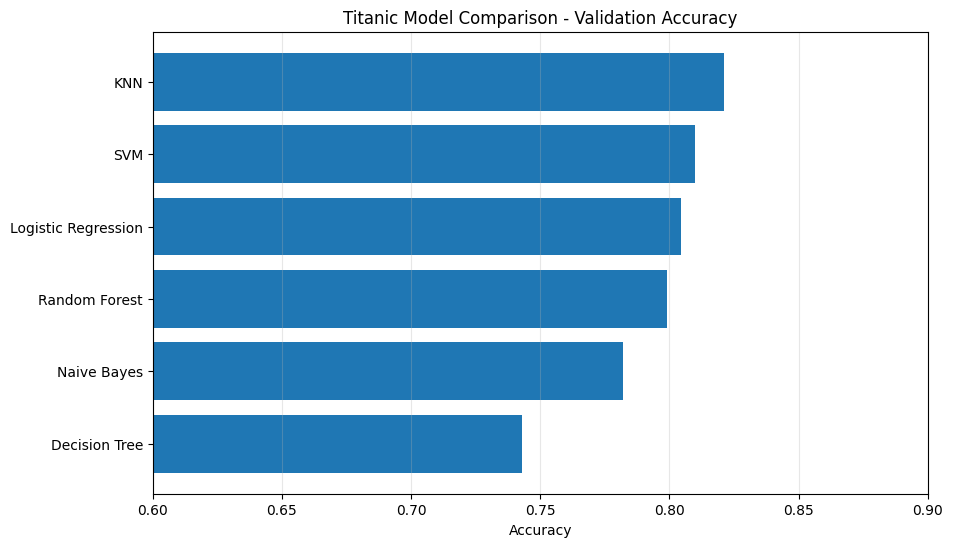

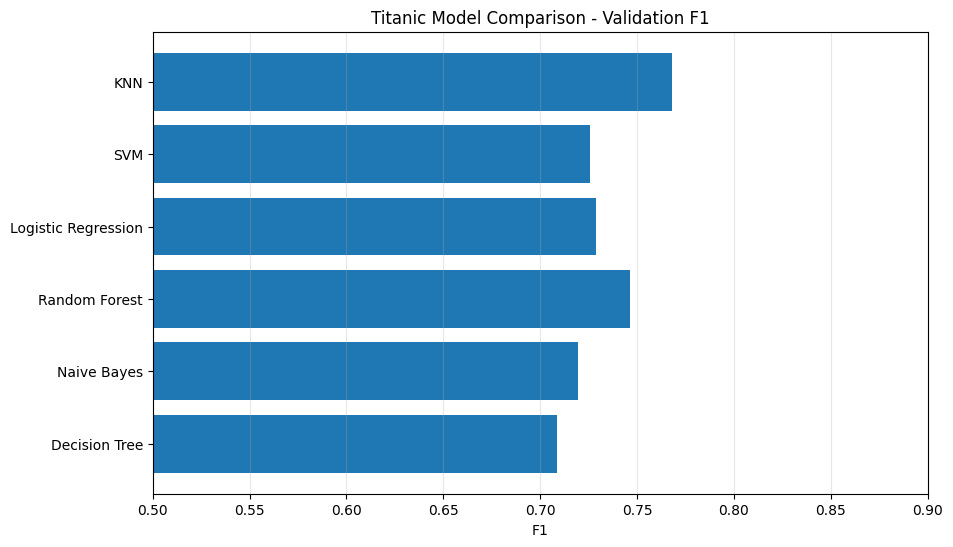

In [4]:
summary_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Valid_Accuracy": r["Valid_Accuracy"],
        "Valid_Precision": r["Valid_Precision"],
        "Valid_Recall": r["Valid_Recall"],
        "Valid_F1": r["Valid_F1"],
        "Valid_ROC_AUC": r["Valid_ROC_AUC"],
        "CV_Accuracy_Mean": r["CV_Accuracy_Mean"],
        "CV_Accuracy_Std": r["CV_Accuracy_Std"],
        "CV_F1_Mean": r["CV_F1_Mean"],
        "CV_ROC_AUC_Mean": r["CV_ROC_AUC_Mean"],
    }
    for r in all_results
])

# 排序規則：先看驗證 Accuracy，再看 F1、ROC-AUC
summary_df = summary_df.sort_values(
    by=["Valid_Accuracy", "Valid_F1", "Valid_ROC_AUC"],
    ascending=False,
).reset_index(drop=True)
summary_df["Rank"] = np.arange(1, len(summary_df) + 1)
summary_df = summary_df[[
    "Rank", "Model",
    "Valid_Accuracy", "Valid_F1", "Valid_ROC_AUC",
    "Valid_Precision", "Valid_Recall",
    "CV_Accuracy_Mean", "CV_Accuracy_Std", "CV_F1_Mean", "CV_ROC_AUC_Mean",
]]

print("=" * 80)
print("最終比較總表")
print("=" * 80)
display(summary_df)

best = summary_df.iloc[0]
print("\n最佳模型統整")
print(f"Model: {best['Model']}")
print(f"Valid Accuracy: {best['Valid_Accuracy']:.4f}")
print(f"Valid F1: {best['Valid_F1']:.4f}")
print(f"Valid ROC-AUC: {best['Valid_ROC_AUC']:.4f}")

summary_df.to_csv("model_comparison_summary.csv", index=False, encoding="utf-8-sig")
print("\n已輸出檔案: model_comparison_summary.csv")

# 視覺化主要指標
plot_df = summary_df.sort_values("Valid_Accuracy", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Model"], plot_df["Valid_Accuracy"])
plt.title("Titanic Model Comparison - Validation Accuracy")
plt.xlabel("Accuracy")
plt.xlim(0.6, 0.9)
plt.grid(axis="x", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Model"], plot_df["Valid_F1"])
plt.title("Titanic Model Comparison - Validation F1")
plt.xlabel("F1")
plt.xlim(0.5, 0.9)
plt.grid(axis="x", alpha=0.3)
plt.show()